# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

1. When the parameters are linear/ linear in the equation
2. The coefficient of a dummy variable represents the difference in the predicted value compared to the reference category, while holding all other variables constant.
3. It can only if it is binary
4. Very good on training idea but pretty bad on testing
5. In the two-stage least squares approach, one correlated variable is first predicted using other variables that are not strongly correlated with it. In the first stage, we estimate the predicted values of that variable. In the second stage, we use those predicted values in the main regression instead of the original correlated variable. This helps reduce the impact of multicollinearity and provides more stable coefficient estimates.
6. Nonlinear relationships can be incorporated by transforming the input variables
7. It tells us the direction and strength of the relationship between the predictor and the outcome.
8. A train/test split divides the dataset into two parts: one portion to train the model and another to evaluate it. This is simple but the evaluation may depend heavily on how the data was split. k fold is divide into k equal parts
9. The value of k is usually chosen based on a balance between computation time and reliability of the estimate. usually around 5 or 10 is common.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [166]:
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()

In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_clean = pd.read_csv('./data/airbnb_hw.csv')
df_clean

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
30473,43022976,8/31/2015,10 Mins to Time Square/two floors,Queens,Apartment,NaN,Entire home/apt,11101.0,5.0,1,0,300,NaN
30474,42993382,8/31/2015,"1BR ocean view & F,Q train st",Brooklyn,Apartment,NaN,Private room,11224.0,2.0,1,0,125,NaN
30475,43033067,8/31/2015,Amazing Private Room,Brooklyn,Other,NaN,Private room,11206.0,1.0,1,0,80,NaN
30476,43000991,8/31/2015,Charming private female room: UWS,Manhattan,Apartment,NaN,Private room,10025.0,1.0,1,0,35,NaN


In [168]:
df_clean['Price'] = pd.to_numeric(df_clean['Price'], errors='coerce')
average = df_clean.groupby('Neighbourhood ')['Price'].mean()
average

,Price
Neighbourhood,
Bronx,83.308140
Brooklyn,124.595122
Manhattan,183.964571
Queens,100.012747
Staten Island,111.312500


<Axes: xlabel='Price', ylabel='Density'>

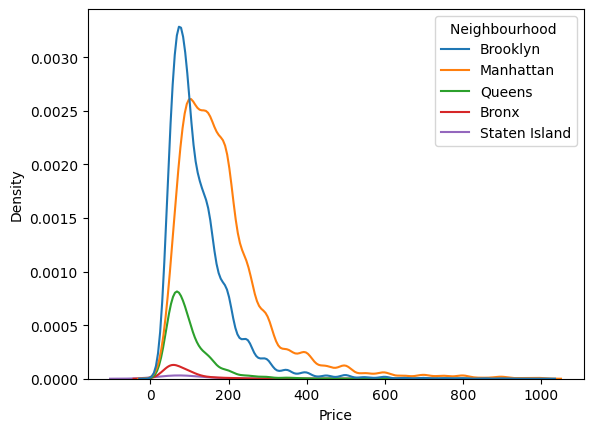

In [169]:
kernel_density_plot = sns.kdeplot(data=df_clean, x='Price', hue='Neighbourhood ')
kernel_density_plot

In [170]:
import statsmodels.api as sm
df = df_clean[['Price','Neighbourhood ', 'Review Scores Rating']].dropna()

one_hot_encoded = pd.get_dummies(df['Neighbourhood '], drop_first=True).astype(int)

x = sm.add_constant(one_hot_encoded)
y = df['Price']

model = sm.OLS(y, x).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.093
Model:                            OLS   Adj. R-squared:                  0.093
Method:                 Least Squares   F-statistic:                     567.0
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        22:39:43   Log-Likelihood:            -1.3213e+05
No. Observations:               22104   AIC:                         2.643e+05
Df Residuals:                   22099   BIC:                         2.643e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            75.2765      6.482     11.612

In [171]:
x2 = sm.add_constant(df['Review Scores Rating'])
y2 = df['Price']

model2 = sm.OLS(y2, x2).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     171.3
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           5.35e-39
Time:                        22:39:43   Log-Likelihood:            -1.3313e+05
No. Observations:               22104   AIC:                         2.663e+05
Df Residuals:                   22102   BIC:                         2.663e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   59.4049 

In [172]:
x3 = sm.add_constant(pd.concat([one_hot_encoded, df['Review Scores Rating']], axis=1))
y3 = df['Price']

model3 = sm.OLS(y3, x3).fit()
print(model3.summary())


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.102
Model:                            OLS   Adj. R-squared:                  0.101
Method:                 Least Squares   F-statistic:                     500.2
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        22:39:43   Log-Likelihood:            -1.3203e+05
No. Observations:               22104   AIC:                         2.641e+05
Df Residuals:                   22098   BIC:                         2.641e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  -21.0833 

In [173]:
interaction_terms = one_hot_encoded.multiply(df['Review Scores Rating'], axis=0)
interaction_terms = interaction_terms.rename(columns=lambda x: f'RSR_x_{x}')
x4 = pd.concat([one_hot_encoded, df['Review Scores Rating'], interaction_terms], axis=1)
x4 = sm.add_constant(x4)
y4 = df['Price']
model4 = sm.OLS(y4, x4).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.102
Model:                            OLS   Adj. R-squared:                  0.102
Method:                 Least Squares   F-statistic:                     278.7
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        22:39:44   Log-Likelihood:            -1.3203e+05
No. Observations:               22104   AIC:                         2.641e+05
Df Residuals:                   22094   BIC:                         2.642e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   22.6384 

In [174]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

model = LinearRegression()

scores_1 = cross_val_score(model, x, y, cv=5, scoring='neg_mean_squared_error')
scores_2 = cross_val_score(model, x2, y2, cv=5, scoring='neg_mean_squared_error')
scores_3 = cross_val_score(model, x3, y3, cv=5, scoring='neg_mean_squared_error')
scores_4 = cross_val_score(model, x4, y4, cv=5, scoring='neg_mean_squared_error')

print("Model 1 CV MSE:", -scores_1.mean())
print("Model 2 CV MSE:", -scores_2.mean())
print("Model 3 CV MSE:", -scores_3.mean())
print("Model 4 CV MSE:", -scores_4.mean())


Model 1 CV MSE: 9155.472510503914
Model 2 CV MSE: 10003.878633823997
Model 3 CV MSE: 9069.797898512628
Model 4 CV MSE: 9067.861644501509


1. Manhattan is most expensive
2. Just the difference in between dummy and the others (in my case bronx)
3. The slope coefficient on Review Scores Rating indicates the expected change in price for a one-unit increase in the review score.
4. The slope is smaller
5. The slopes are way different

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [175]:
df_cars = pd.read_csv('./data/cars_hw.csv')
df_cars

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000
...,...,...,...,...,...,...,...,...,...,...,...,...
971,972,Hyundai,2018,white,sedan,23869,1st,5,petrol,6-Speed,Automatic,956000
972,973,Hyundai,2019,white,sedan,14831,1st,5,petrol,6-Speed,Automatic,1027000
973,974,Hyundai,2014,silver,sedan,52846,1st,5,petrol,4-Speed,Automatic,736000
974,975,Ford,2020,white,crossover,28335,2nd,5,diesel,5-Speed,Automatic,749000


In [176]:
summary = df_cars['Price'].describe()
summary

,Price
count,9.760000e+02
mean,7.410195e+05
std,3.673234e+05
min,1.880000e+05
25%,4.757500e+05
50%,6.665000e+05
75%,8.830000e+05
max,2.941000e+06


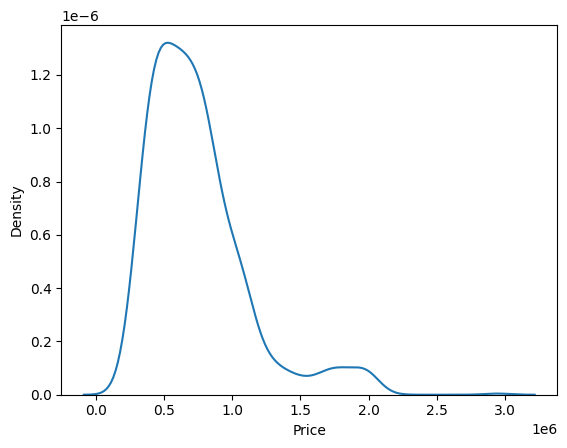

In [177]:
kernel_density_plot = sns.kdeplot(data=df_cars, x='Price')

In [178]:
summary_body = df_cars.groupby('Body_Type')['Price'].describe()
summary_body

,count,mean,std,min,25%,50%,75%,max
Body_Type,,,,,,,,
crossover,21.0,7.050952e+05,72849.780207,608000.0,638000.0,706000.0,749000.0,883000.0
hatchback,484.0,5.339773e+05,173086.729837,188000.0,401750.0,509000.0,661000.0,1107000.0
muv,38.0,6.264211e+05,184093.488526,328000.0,489750.0,621500.0,738500.0,1091000.0
sedan,227.0,8.097841e+05,286736.770092,368000.0,598000.0,772000.0,968500.0,2941000.0
suv,206.0,1.176495e+06,417479.028217,559000.0,860000.0,1065000.0,1491250.0,2100000.0


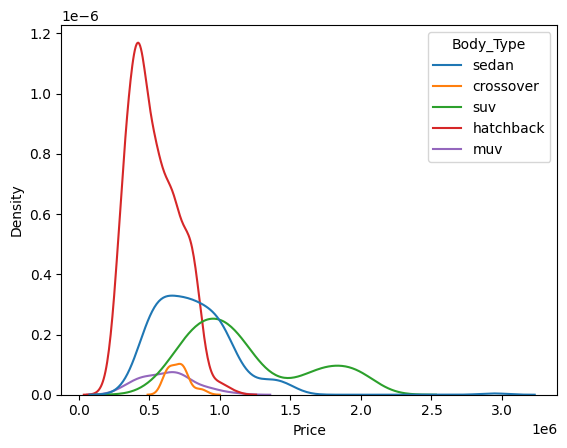

In [179]:
group_kernel_density_plot = sns.kdeplot(data=df_cars, x='Price', hue='Body_Type')


In [180]:
x = sm.add_constant(df_cars['Seating_Capacity'])
y = df_cars['Price']

model = sm.OLS(y, x).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Fri, 13 Mar 2026   Prob (F-statistic):             0.0245
Time:                        22:39:45   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              4.39e+05   1.35e+05  

In [181]:
one_hot_encoded = pd.get_dummies(df_cars['Seating_Capacity'], drop_first=True).astype(int)
x = sm.add_constant(one_hot_encoded)
y = df_cars['Price']

model = sm.OLS(y, x).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     5.397
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           0.000267
Time:                        22:39:45   Log-Likelihood:                -13880.
No. Observations:                 976   AIC:                         2.777e+04
Df Residuals:                     971   BIC:                         2.779e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        1.88e+05   3.64e+05      0.516      0.6

In [182]:
age = 2026 - df_cars['Make_Year']
df_cars['Age'] = age
x = sm.add_constant(df_cars['Age'])
y = df_cars['Price']

mse_scores = []
optimal_degree = 0
best_mse = float('inf')

from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import KFold

for degree in range(1, 10):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(x)

    model = LinearRegression()
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_poly, y, cv=kf, scoring='neg_mean_squared_error')
    mean_mse = -scores.mean()
    mse_scores.append(mean_mse)

    print(f"Degree {degree}: Mean Squared Error = {mean_mse:.2f}")

    if mean_mse < best_mse:
        best_mse = mean_mse
        optimal_degree = degree

print(f"\nThe optimal number of powers for Age is {optimal_degree} with a Mean Squared Error of {best_mse:.2f}")


Degree 1: Mean Squared Error = 97377248064.00
Degree 2: Mean Squared Error = 97395705968.64
Degree 3: Mean Squared Error = 96743204818.44
Degree 4: Mean Squared Error = 96225038252.26
Degree 5: Mean Squared Error = 95265035513.84
Degree 6: Mean Squared Error = 95358958403.24
Degree 7: Mean Squared Error = 94688972031.68
Degree 8: Mean Squared Error = 93877912168.79
Degree 9: Mean Squared Error = 94204967920.41

The optimal number of powers for Age is 8 with a Mean Squared Error of 93877912168.79


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


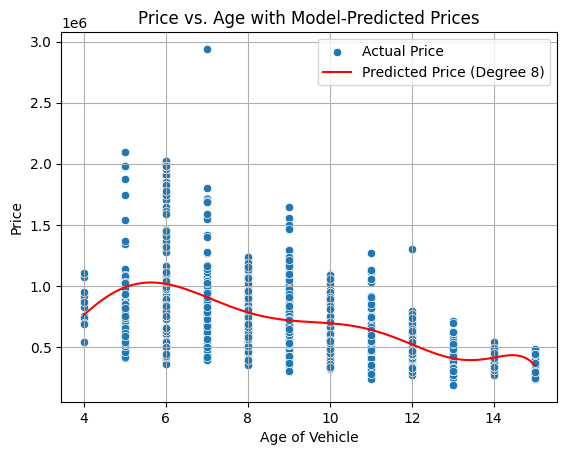

In [183]:
optimal_degree = 8

X_age_only = df_cars[['Age']]
y = df_cars['Price']

poly = PolynomialFeatures(degree=optimal_degree, include_bias=False)
X_poly_transformed = poly.fit_transform(X_age_only)

X_final = sm.add_constant(X_poly_transformed)

model = LinearRegression()
model.fit(X_final, y)

age_for_plotting = np.linspace(df_cars['Age'].min(), df_cars['Age'].max(), 100).reshape(-1, 1)
age_poly_for_plotting = poly.transform(age_for_plotting)
X_pred_plot = np.hstack((np.ones((age_poly_for_plotting.shape[0], 1)), age_poly_for_plotting))
predicted_prices_plot = model.predict(X_pred_plot)

sns.scatterplot(data=df_cars, x='Age', y='Price', label='Actual Price')
sns.lineplot(x=age_for_plotting.flatten(), y=predicted_prices_plot, color='red', label=f'Predicted Price (Degree {optimal_degree})')

plt.title('Price vs. Age with Model-Predicted Prices')
plt.xlabel('Age of Vehicle')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


1. SUVs on average are the most expensive while sedans have the most variance
2. It means as capacity increases by one it should increase price by around 59k. The price increase can vary based on other variables
3. The prediction does manage to get the trend but it is not perfect

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [184]:
df_heart = pd.read_csv('./data/heart_hw.csv')
df_heart

,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0
...,...,...,...,...
98,99,30,control,1
99,100,48,treatment,1
100,101,40,treatment,1
101,102,48,treatment,1


In [185]:
control_proportion = df_heart[df_heart['transplant'] == 'control']['y'].mean()
treatment_proportion = df_heart[df_heart['transplant'] == 'treatment']['y'].mean()


In [186]:
control_proportion


np.float64(0.11764705882352941)

In [187]:
treatment_proportion

np.float64(0.34782608695652173)

In [188]:
ATE = treatment_proportion - control_proportion
ATE

np.float64(0.23017902813299232)

In [189]:
x = sm.add_constant(df_heart['transplant'].map({'control': 0, 'treatment': 1}))
y = df_heart['y']

model = sm.OLS(y, x).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Fri, 13 Mar 2026   Prob (F-statistic):             0.0133
Time:                        22:39:46   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1176      0.075      1.574      0.1

In [190]:
x2 = sm.add_constant(pd.concat([df_heart['transplant'].map({'control': 0, 'treatment': 1}), df_heart['age']], axis=1))
y2 = df_heart['y']

model2 = sm.OLS(y2, x2).fit()
print(model2.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           0.000357
Time:                        22:39:46   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7020      0.196      3.583      0.0

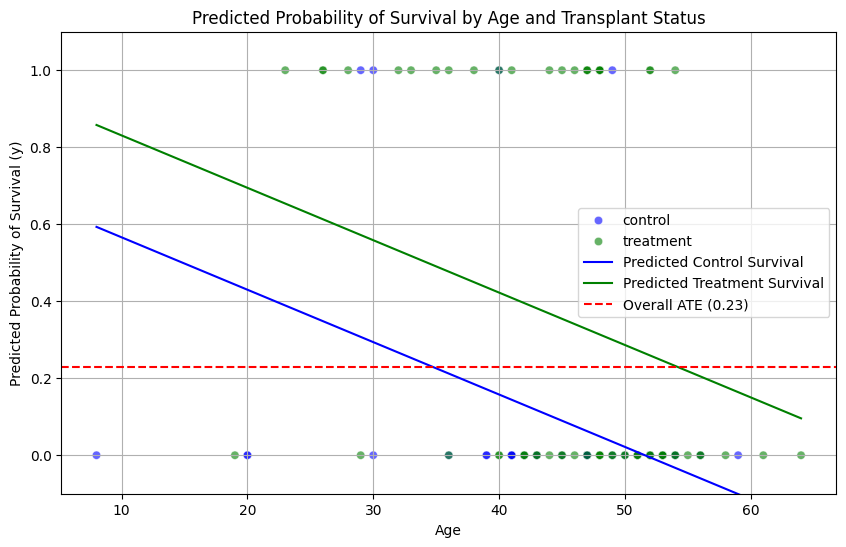

In [191]:
const_coef = model2.params['const']
transplant_coef = model2.params['transplant']
age_coef = model2.params['age']

age_range = np.linspace(df_heart['age'].min(), df_heart['age'].max(), 100)

pred_control = const_coef + (transplant_coef * 0) + (age_coef * age_range)
pred_treatment = const_coef + (transplant_coef * 1) + (age_coef * age_range)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='y', data=df_heart, hue='transplant', alpha=0.6, palette={'control': 'blue', 'treatment': 'green'})
plt.plot(age_range, pred_control, color='blue', linestyle='-', label='Predicted Control Survival')
plt.plot(age_range, pred_treatment, color='green', linestyle='-', label='Predicted Treatment Survival')
plt.axhline(y=ATE, color='red', linestyle='--', label=f'Overall ATE ({ATE:.2f})')

plt.title('Predicted Probability of Survival by Age and Transplant Status')
plt.xlabel('Age')
plt.ylabel('Predicted Probability of Survival (y)')
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid(True)
plt.show()

In [195]:
transplant_numeric = df_heart['transplant'].map({'control': 0, 'treatment': 1})
x3 = sm.add_constant(pd.concat([transplant_numeric, df_heart['age'], transplant_numeric * df_heart['age']], axis=1))

x3.columns = x3.columns.astype(str)
y3 = df_heart['y']

model3 = sm.OLS(y3, x3).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           0.000310
Time:                        22:40:04   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3549      0.280      1.269      0.2

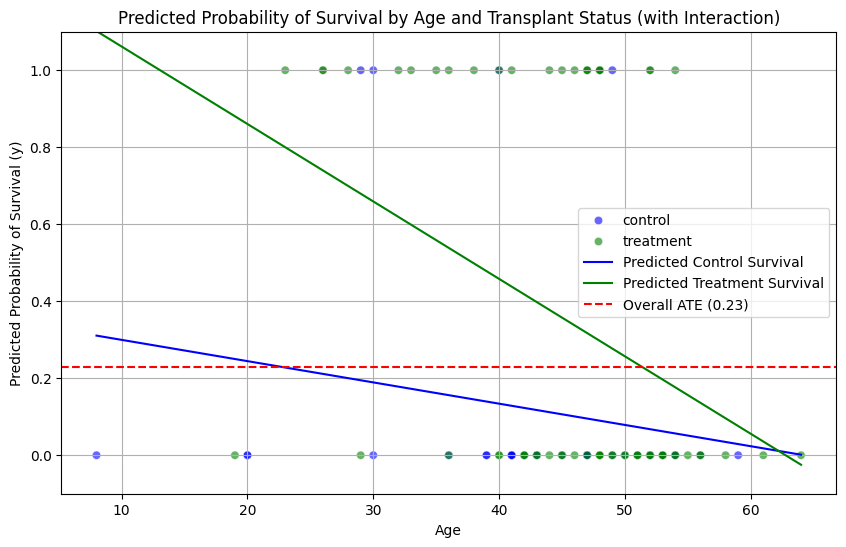

In [193]:
const_coef = model3.params['const']
transplant_coef = model3.params['transplant']
age_coef = model3.params['age']

interaction_coef = model3.params['0']

age_range = np.linspace(df_heart['age'].min(), df_heart['age'].max(), 100)


pred_control = const_coef + (age_coef * age_range)

pred_treatment = const_coef + transplant_coef + (age_coef * age_range) + (interaction_coef * age_range)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='y', data=df_heart, hue='transplant', alpha=0.6, palette={'control': 'blue', 'treatment': 'green'})
plt.plot(age_range, pred_control, color='blue', linestyle='-', label='Predicted Control Survival')
plt.plot(age_range, pred_treatment, color='green', linestyle='-', label='Predicted Treatment Survival')
plt.axhline(y=ATE, color='red', linestyle='--', label=f'Overall ATE ({ATE:.2f})')

plt.title('Predicted Probability of Survival by Age and Transplant Status (with Interaction)')
plt.xlabel('Age')
plt.ylabel('Predicted Probability of Survival (y)')
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid(True)
plt.show()

In [194]:
model = LinearRegression()


scores_1 = cross_val_score(model, x, y, cv=10, scoring='neg_mean_squared_error')
scores_2 = cross_val_score(model, x2, y2, cv=10, scoring='neg_mean_squared_error')
scores_3 = cross_val_score(model, x3, y3, cv=10, scoring='neg_mean_squared_error')


print("Model 1 CV Mean Squared Error:", -scores_1.mean())
print("Model 2 CV Mean Squared Error:", -scores_2.mean())
print("Model 3 CV Mean Squared Error:", -scores_3.mean())

Model 1 CV Mean Squared Error: 0.20970277289824915
Model 2 CV Mean Squared Error: 0.19922806049232314
Model 3 CV Mean Squared Error: 0.19609811380122738


1. ATE is 0.23017902813299232 / ~23%
2. Well the transplant coeff should be the same as ATE since it is just the difference between them
3. When you control for age, the estimated effect of transplant increases. This suggests that age was negatively correlated with receiving a transplant (older patients may be less likely to get one), so controlling for age reveals a slightly larger effect. Fairly accurate for all ages since close to ATE / transplant coefficient. Rveals that age does have an affect on transplants
4. Model 3 has a higher transplant coefficient and it overestimates for older while underestimates for younger. It has a lot more distinct impact rather than the parallel of model 2. Noticed same pattern in all, older you get the less effective transplant will be
5. I have some concerns about overreliance and where the data is coming from. It doesn't mean older people should have less prio than younger ones. Also this is not a usual regression task.